In [11]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

In [12]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [13]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_lieux = []

for year in years:
    df_lieux_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"lieux-{year}.csv"), encoding="utf-8", sep = ";", dtype=str)
    df_lieux.append(df_lieux_year)

df_lieux = pandas.concat(df_lieux)
df_lieux

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,201900000001,1,3,0,NaN,3,10,0,1,6,900,2,NaN,NaN,1,2,1,70
1,201900000002,1,1,0,NaN,1,2,0,4,3,845,2,NaN,NaN,1,0,1,70
2,201900000003,1,86,0,NaN,3,8,0,1,10,500,3,NaN,NaN,1,0,1,90
3,201900000004,1,4,0,NaN,3,5,0,1,2,299,1,NaN,NaN,1,0,1,90
4,201900000005,1,86,0,INT,1,3,0,1,41,0,3,NaN,NaN,1,2,1,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70243,202400054398,3,NaN,-1,NaN,1,1,-1,1,-1,-1,1,NaN,-1,2,5,4,-1
70244,202400054399,3,RUE PIERRE GAUDIN,0,NaN,1,1,2,1,0,0,2,NaN,-1,1,0,1,30
70245,202400054400,2,12,0,NaN,1,2,0,2,31,1 000,1,NaN,10,1,0,1,110
70246,202400054401,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,0,NaN,2,3,0,1,0,0,1,NaN,"10,5",1,0,1,50


In [14]:
column_names_to_int = ['Num_Acc', 'catr', 'v1', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf',
       'infra', 'situ', 'vma']

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [15]:
df_lieux.replace(-1, pandas.NA, inplace=True)

for col in df_lieux.columns:
    prop = df_lieux[col].isna().sum() / len(df_lieux)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For catr proportion missing: 0.00%
For voie proportion missing: 13.67%
For v1 proportion missing: 20.02%
For v2 proportion missing: 91.91%
For circ proportion missing: 6.00%
For nbv proportion missing: 2.97%
For vosp proportion missing: 2.53%
For prof proportion missing: 0.08%
For pr proportion missing: 15.90%
For pr1 proportion missing: 15.97%
For plan proportion missing: 0.07%
For lartpc proportion missing: 99.84%
For larrout proportion missing: 86.00%
For surf proportion missing: 0.09%
For infra proportion missing: 1.10%
For situ proportion missing: 0.11%
For vma proportion missing: 3.23%


In [16]:
# First we are dropping features that we are not going to use
df_lieux.drop(columns = ['voie', 'v1', 'v2', 'pr', 'pr1', 'lartpc', 'larrout'], inplace = True)


In [17]:
df_lieux["vma"].value_counts().sort_index()

vma
0           2
1          88
2          59
3          17
4           5
5         149
6          36
7           3
8           2
9           1
10        658
12          2
15        200
16          1
20       1137
23          1
25        222
30      49801
31          1
35         21
40        360
42          1
45        117
50     179006
55          3
60        898
65          4
70      23949
75          5
80      47971
85          1
90      25332
95          1
100        55
110     11494
120         1
130      6212
140         2
180         1
300         9
301         1
500        62
501         1
502         1
520         1
560         1
600         1
700         5
770         1
800         2
900         6
901         1
Name: count, dtype: int64

In [18]:
df_lieux = df_lieux[(df_lieux['vma'] >= 0) & (df_lieux['vma'] <= 130)]

In [19]:

df_lieux = df_lieux.copy()  # évite SettingWithCopyWarning

df_lieux["vma"] = pandas.to_numeric(df_lieux["vma"], errors="coerce")

df_lieux["vma"] = df_lieux.groupby("catr")["vma"].transform(
    lambda x: x.fillna(x.median()) 
)

In [20]:
imputer = SimpleImputer(strategy="most_frequent")

small_na_cols = df_lieux.columns[(df_lieux.isna().sum() < 50000) & (df_lieux.isna().sum() > 0)]
df_lieux[small_na_cols] = df_lieux[small_na_cols].replace({pandas.NA: np.nan})

df_lieux[small_na_cols ] = imputer.fit_transform(df_lieux[small_na_cols])

In [21]:
df_lieux.columns

Index(['Num_Acc', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma'],
      dtype='str')

In [22]:
# And converting to int
column_names_to_int = ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ']

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].astype("int64")
df_lieux["vma"] = df_lieux["vma"].astype("float64")

In [23]:
df_lieux["vma"].value_counts().sort_index()

vma
0.0           2
1.0          88
2.0          59
3.0          17
4.0           5
5.0         149
6.0          36
7.0           3
8.0           2
9.0           1
10.0        658
12.0          2
15.0        200
16.0          1
20.0       1137
23.0          1
25.0        222
30.0      49801
31.0          1
35.0         21
40.0        360
42.0          1
45.0        117
50.0     179006
55.0          3
60.0        898
65.0          4
70.0      23949
75.0          5
80.0      47971
85.0          1
90.0      25332
95.0          1
100.0        55
110.0     11494
120.0         1
130.0      6212
Name: count, dtype: int64

In [24]:
features = column_names_to_int + ["vma"]
categorical_features = column_names_to_int
numerical_features = ["vma"]

In [25]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_lieux_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(
    df_lieux,
    on='Num_Acc',
    how='left'
)

target = "grav_bin"

In [26]:
df_lieux_with_target = df_lieux_with_target.dropna()

In [27]:
df_lieux_analyse = df_lieux_with_target.copy() 

mapping = {
1: "Autoroute",  
2: "Route nationale",  
3: "Route Départementale",  
4: "Voie Communales",  
5: "Hors réseau public",  
6: "Parc de stationnement ",  
7: "Routes de métropole urbaine",  
9: "Autre" }
df_lieux_analyse["catr"] = df_lieux_analyse["catr"].replace(mapping)

mapping = {
1: "A sens unique",
2: "Bidirectionnelle",
3: "A chaussées séparées",
4: "Avec voies d’affectation variable" }
df_lieux_analyse["circ"] = df_lieux_analyse["circ"].replace(mapping)

# nbvp - ok

mapping = {
0: "Sans objet",
1: "Piste cyclable",
2: "Bande cyclable",
3: "Voie réservée"
}
df_lieux_analyse["vosp"] = df_lieux_analyse["vosp"].replace(mapping)

mapping = {
1: "Plat",  
2: "Pente",  
3: "Sommet de côte",  
4: "Bas de côte" }
df_lieux_analyse["prof"] = df_lieux_analyse["prof"].replace(mapping)

mapping = {
1: "Partie rectiligne",  
2: "En courbe à gauche",  
3: "En courbe à droite", 
4: "En « S »"}
df_lieux_analyse["plan"] = df_lieux_analyse["plan"].replace(mapping)

mapping = {
1: "Normale",   
2: "Mouillée",   
3: "Flaques",   
4: "Inondée",   
5: "Enneigée",   
6: "Boue",  
7: "Verglacée",   
8: "Corps gras – huile",   
9: "Autre"}
df_lieux_analyse["surf"] = df_lieux_analyse["surf"].replace(mapping)

mapping = {
0: "Aucun",   
1: "Souterrain - tunnel",  
2: "Pont - autopont",  
3: "Bretelle d’échangeur ou de raccordement",  
4: "Voie ferrée",  
5: "Carrefour aménagé",  
6: "Zone piétonne",  
7: "Zone de péage",  
8: "Chantier",  
9: "Autres" }
df_lieux_analyse["infra"] = df_lieux_analyse["infra"].replace(mapping)

mapping = {
0: "Aucun",
1: "Sur chaussée",  
2: "Sur bande d’arrêt d’urgence",  
3: "Sur accotement",  
4: "Sur trottoir",  
5: "Sur piste cyclable",  
6: "Sur autre voie spéciale",  
8: "Autres"}
df_lieux_analyse["situ"] = df_lieux_analyse["situ"].replace(mapping)

# vma - ok

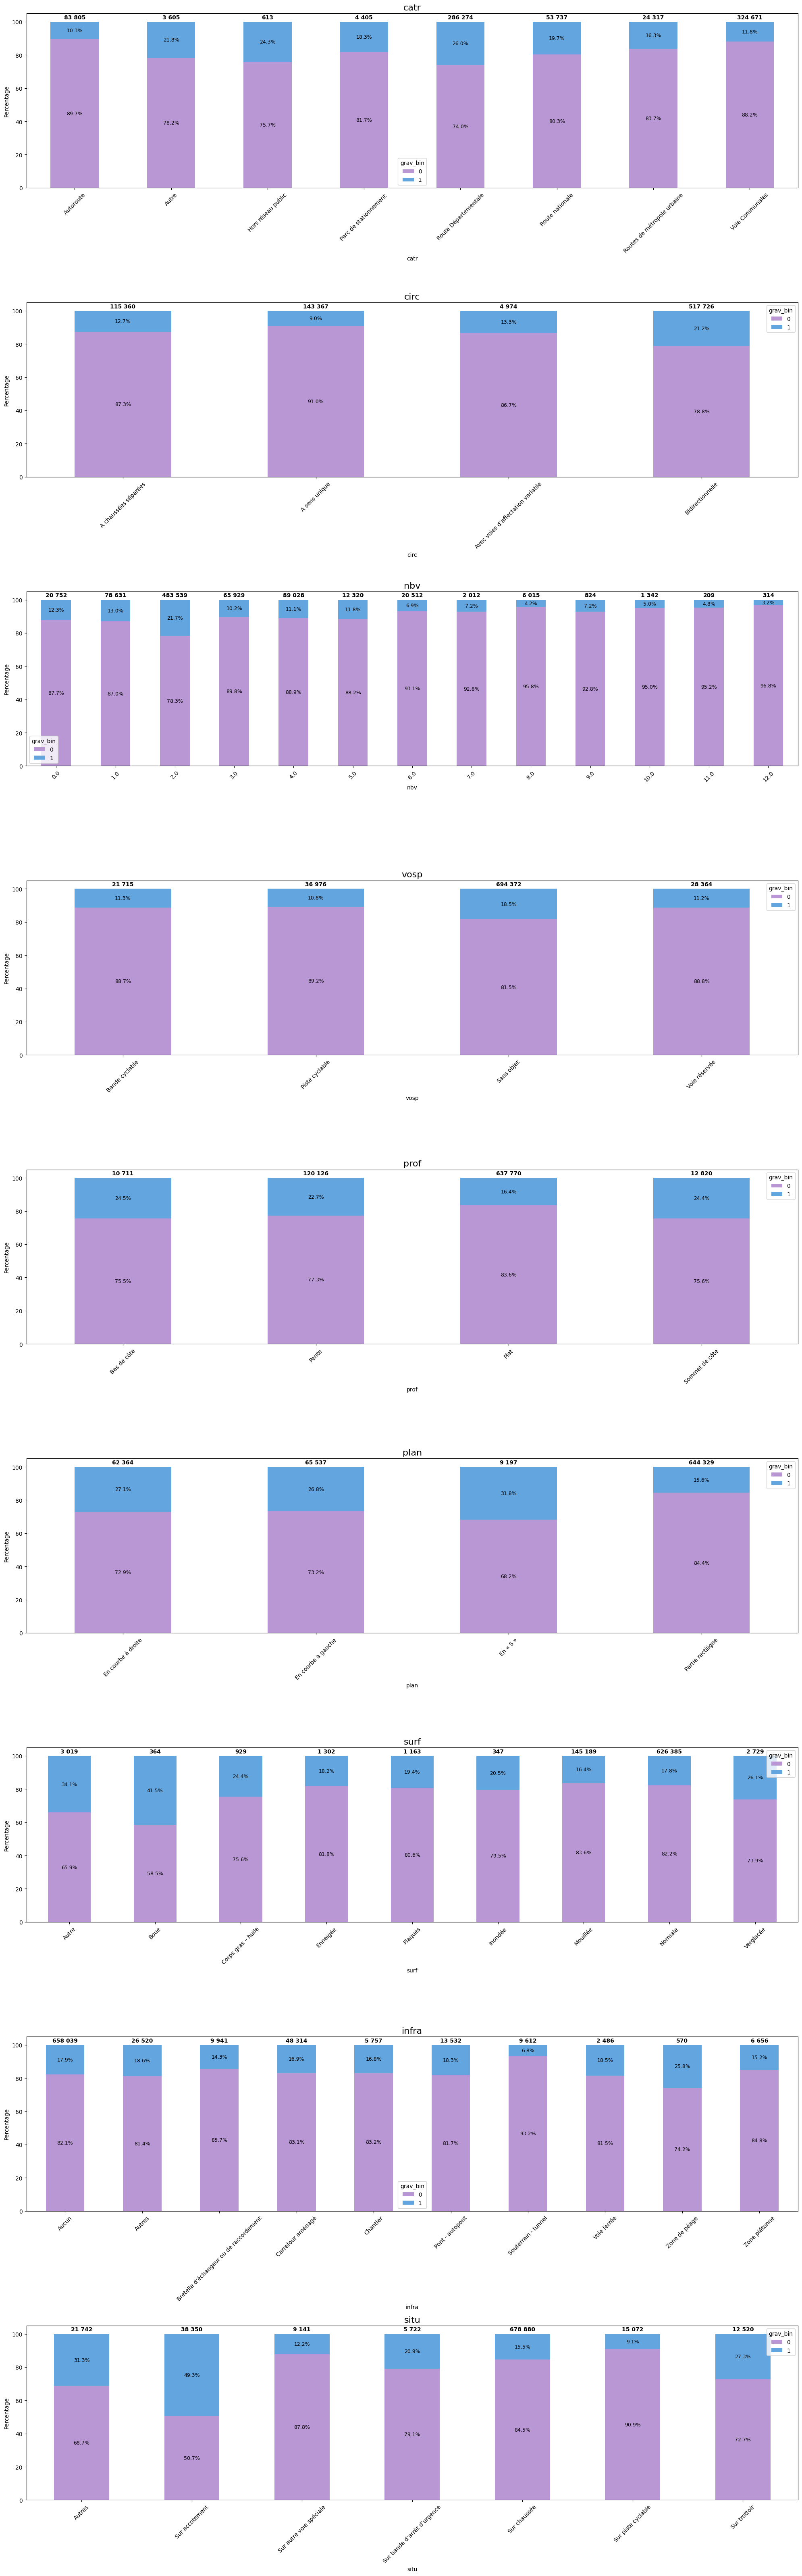

In [28]:
fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

df_lieux_analyse = df_lieux_analyse.reset_index(drop=True)

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_lieux_analyse[feature],
        df_lieux_analyse[target],
        normalize="index"
    ) * 100

    counts = df_lieux_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

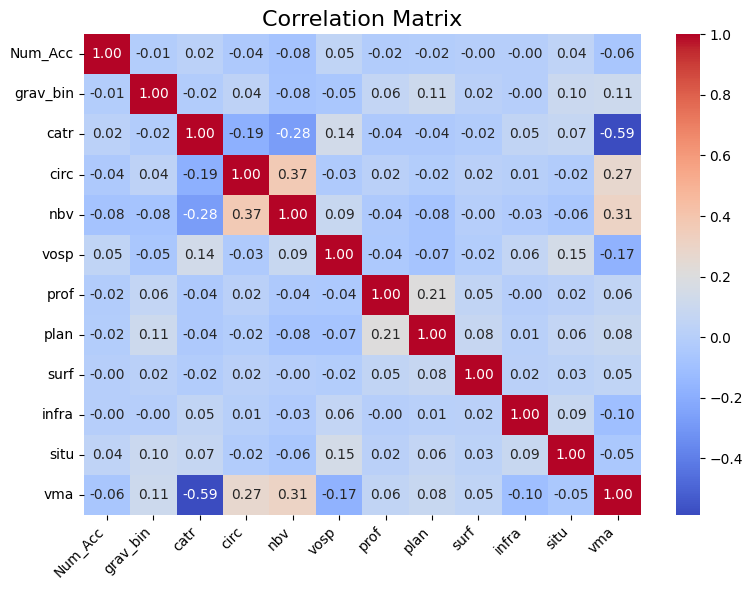

In [29]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df_lieux_with_target.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [30]:
X = df_lieux_with_target[categorical_features + numerical_features]
y = df_lieux_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

for name, pipe in pipelines.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))



 Logistic Regression
Precision: 0.5678012695556556
Recall: 0.10299464174002919
F1: 0.1743614931237721
Accuracy: 0.8279044247617737
              precision    recall  f1-score   support

           0       0.84      0.98      0.90    514844
           1       0.57      0.10      0.17    110297

    accuracy                           0.83    625141
   macro avg       0.70      0.54      0.54    625141
weighted avg       0.79      0.83      0.78    625141


 Decision Tree
Precision: 0.4989456946316845
Recall: 0.1308648467320054
F1: 0.2073463289902748
Accuracy: 0.8234670258389707
              precision    recall  f1-score   support

           0       0.84      0.97      0.90    514844
           1       0.50      0.13      0.21    110297

    accuracy                           0.82    625141
   macro avg       0.67      0.55      0.55    625141
weighted avg       0.78      0.82      0.78    625141


 Gradient Boosting
Precision: 0.571685947278589
Recall: 0.10932300969201338
F1: 0.183546

In [32]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_val, y_pred))


 Logistic Regression
Precision: 0.5697934809654143
Recall: 0.10432801822323462
F1: 0.17636412645846972
Accuracy: 0.8284019125285336
              precision    recall  f1-score   support

           0       0.84      0.98      0.90    103079
           1       0.57      0.10      0.18     21950

    accuracy                           0.83    125029
   macro avg       0.70      0.54      0.54    125029
weighted avg       0.79      0.83      0.78    125029


 Decision Tree
Precision: 0.6604019352437663
Recall: 0.16168564920273348
F1: 0.2597716293368467
Accuracy: 0.8284019125285336
              precision    recall  f1-score   support

           0       0.85      0.98      0.91    103079
           1       0.66      0.16      0.26     21950

    accuracy                           0.84    125029
   macro avg       0.75      0.57      0.58    125029
weighted avg       0.81      0.84      0.80    125029


 Gradient Boosting
Precision: 0.5733586157857312
Recall: 0.11020501138952164
F1: 0.184

AUC of Logistic Regression: 0.711
AUC of Decision Tree: 0.693
AUC of Gradient Boosting: 0.716


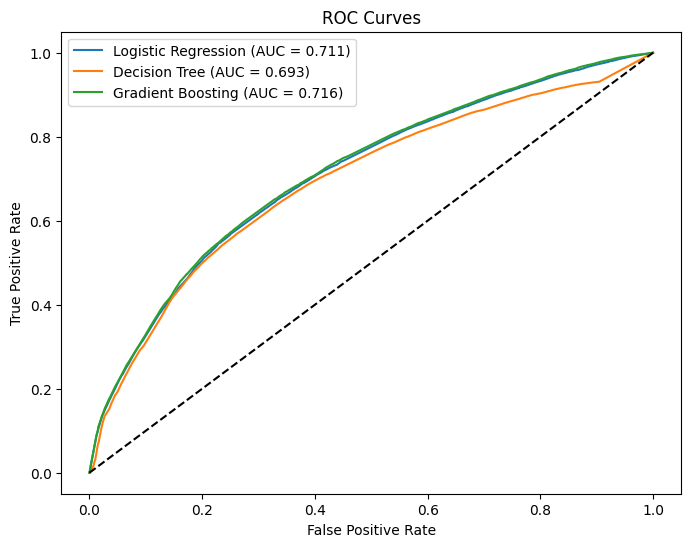

In [33]:
plt.figure(figsize=(8,6))
lst_auc = []

for name, pipe in pipelines.items(): 
    if hasattr(pipe["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe["model"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

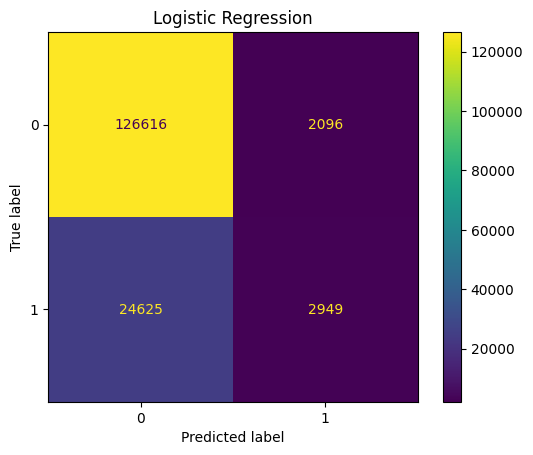

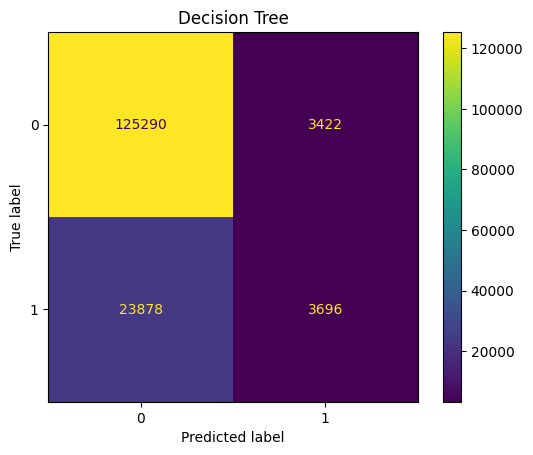

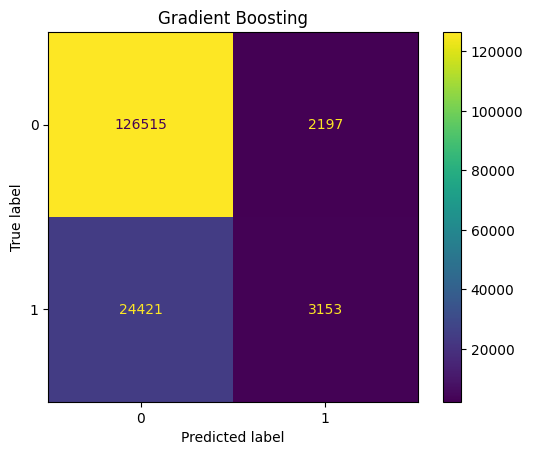

In [34]:
for name, model in pipelines.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

In [35]:
# Finally we are going to save the dataset cleaned
df_lieux.to_csv("df_lieux_clean.csv", index=False)

In [36]:
df_lieux = pandas.read_csv("df_lieux_clean.csv")

In [37]:
print("All columns:", df_lieux.columns)
print("Features:", features)

All columns: Index(['Num_Acc', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma'],
      dtype='str')
Features: ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf', 'infra', 'situ', 'vma']
